# 온라인 쇼핑객 Revenue 예측 - Random Forest 모델 분석

전처리 산출물 `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`를 사용해 Random Forest 모델을 학습하고 평가한다. 모델 선택 과정, 최종 성능, 해석 지표를 순서대로 확인하고, K-Means 군집 변수를 추가한 비교 실험은 별도 섹션에서 다룬다.

노트북 구성:
- 1. 데이터 및 평가 준비
- 2. Random Forest 모델 분석
- 3. RF + K-Means 연계 실험
- 4. 상세 지표 및 참고 출력


In [1]:
%matplotlib inline

from pathlib import Path
import sys
import subprocess
import warnings

modules = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
}
for mod, package in modules.items():
    try:
        __import__(mod)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

RANDOM_STATE = 42
plt.rcParams['figure.figsize'] = (8, 4.5)


Matplotlib is building the font cache; this may take a moment.


### 분석 환경과 재현성

`RandomForestClassifier`를 중심 모델로 사용하고, `KMeans`는 군집 정보를 추가 변수로 붙이는 비교 실험에서 사용한다. `RANDOM_STATE=42`는 train/validation 분리, 튜닝, 군집화 결과를 동일하게 재현하기 위한 고정값이다.


## 1. 데이터 및 평가 준비

데이터 위치를 확인하고, 누수 컬럼 제거 여부와 평가 기준을 점검한다. IQR 제거 데이터는 최종 모델 변경용이 아니라 민감도 분석용 비교군으로만 사용한다.

---


### 1.1 데이터 로드

현재 노트북 위치와 상위 폴더를 탐색해 루트의 전처리 산출물을 읽는다. `PageValues`가 남아 있으면 누수 가능성이 있으므로 제거한다.


In [2]:
def find_data_dir():
    required = ['X_train.csv', 'X_test.csv', 'y_train.csv', 'y_test.csv']
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([
            base / 'csv',
            base / 'models' / 'random_forest' / 'csv',
            base,
        ])
    for base in candidates:
        if all((base / name).exists() for name in required):
            return base
    raise FileNotFoundError('RF용 X/y train/test CSV 파일을 찾지 못했습니다.')

DATA_DIR = find_data_dir()
X_train_raw = pd.read_csv(DATA_DIR / 'X_train.csv')
X_test_raw = pd.read_csv(DATA_DIR / 'X_test.csv')
y_train = pd.read_csv(DATA_DIR / 'y_train.csv').iloc[:, 0].astype(int).reset_index(drop=True)
y_test = pd.read_csv(DATA_DIR / 'y_test.csv').iloc[:, 0].astype(int).reset_index(drop=True)

# PageValues는 구매 이후 정보에 가까워 누수 위험이 있으므로 있으면 제거한다.
leakage_cols = [col for col in ['PageValues'] if col in X_train_raw.columns]
X_train = X_train_raw.drop(columns=leakage_cols).reset_index(drop=True)
X_test = X_test_raw.drop(columns=leakage_cols).reset_index(drop=True)

print(f'Data directory: {DATA_DIR}')
print(f'Train: {X_train.shape}, positive ratio: {y_train.mean():.4f}')
print(f'Test : {X_test.shape}, positive ratio: {y_test.mean():.4f}')
print(f'Removed leakage columns: {leakage_cols if leakage_cols else "None"}')
print(f'Feature count: {X_train.shape[1]}')
X_train.head()


Data directory: /Users/hyunkim/2026_2/datamining/shopper-prediction/models/random_forest/csv
Train: (9764, 31), positive ratio: 0.1563
Test : (2441, 31), positive ratio: 0.1565
Removed leakage columns: None
Feature count: 31


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,SpecialDay,OperatingSystems,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_New_Visitor,VisitorType_Other,VisitorType_Returning_Visitor
0,8,203.6,1,0.0,42,1052.400000,0.0,0.004545,0.0,2,...,0,0,0,0,1,0,0,0,0,1
1,0,0.0,0,0.0,30,901.288889,0.0,0.007333,0.0,2,...,0,0,0,0,0,0,0,1,0,0
2,0,0.0,0,0.0,13,421.166667,0.0,0.028205,0.8,1,...,0,0,0,1,0,0,0,0,0,1
3,2,40.0,0,0.0,5,558.500000,0.0,0.028571,0.0,2,...,0,0,1,0,0,0,0,1,0,0
4,0,0.0,0,0.0,16,1599.266667,0.0,0.013333,0.0,4,...,0,0,0,1,0,0,0,0,0,1


### 데이터 구성 확인

입력 변수 `X_train`, `X_test`와 정답 `y_train`, `y_test`를 불러온다. `PageValues`는 구매 결과와 직접 연결될 수 있는 누수 후보라서 발견되면 제거한다. positive ratio는 구매 클래스 비율이며, 약 15%대의 불균형 분류 문제임을 보여준다.


### 1.2 IQR 민감도 분석용 극단값 제거

다른 모델과의 비교 일관성을 위해 최종 Random Forest는 극단값을 제거하지 않은 raw tree 입력을 기본으로 사용한다. 아래 IQR 기준 데이터는 행 제거가 성능과 표본 구성에 미치는 영향을 확인하는 민감도 분석용으로만 둔다.


In [3]:
OUTLIER_CANDIDATES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'SpecialDay',
    'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio',
]
outlier_cols = [col for col in OUTLIER_CANDIDATES if col in X_train.columns]

q1 = X_train[outlier_cols].quantile(0.25)
q3 = X_train[outlier_cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
active_outlier_cols = iqr[iqr > 0].index.tolist()

def inlier_mask(X):
    if not active_outlier_cols:
        return pd.Series(True, index=X.index)
    return ((X[active_outlier_cols] >= lower[active_outlier_cols]) &
            (X[active_outlier_cols] <= upper[active_outlier_cols])).all(axis=1)

train_mask = inlier_mask(X_train)
test_mask = inlier_mask(X_test)

X_train_clean = X_train.loc[train_mask].reset_index(drop=True)
y_train_clean = y_train.loc[train_mask].reset_index(drop=True)
X_test_clean = X_test.loc[test_mask].reset_index(drop=True)
y_test_clean = y_test.loc[test_mask].reset_index(drop=True)

removed_train = len(X_train) - len(X_train_clean)
removed_test = len(X_test) - len(X_test_clean)
print(f'Outlier columns: {active_outlier_cols}')
print(f'Train removed: {removed_train:,} / {len(X_train):,} ({removed_train / len(X_train):.2%})')
print(f'Test removed : {removed_test:,} / {len(X_test):,} ({removed_test / len(X_test):.2%})')
print(f'Clean train: {X_train_clean.shape}, positive ratio: {y_train_clean.mean():.4f}')
print(f'Clean test : {X_test_clean.shape}, positive ratio: {y_test_clean.mean():.4f}')


Outlier columns: ['Administrative', 'Administrative_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'total_pages', 'total_duration', 'avg_time_per_product', 'bounce_exit_ratio']
Train removed: 3,303 / 9,764 (33.83%)
Test removed : 813 / 2,441 (33.31%)
Clean train: (6461, 31), positive ratio: 0.1568
Clean test : (1628, 31), positive ratio: 0.1548


### IQR 민감도 분석 해석

IQR 제거 데이터는 극단값 제거가 표본 구성과 성능에 주는 영향을 확인하기 위한 비교군이다. Random Forest는 트리 기반 모델이라 극단값에 비교적 강하므로, 메인 평가는 raw test 기준을 유지한다.


### 1.3 평가 함수

불균형 분류이므로 Accuracy만 보지 않고 Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 본다.

특히 F1은 Precision과 Recall의 조화평균이라서, 구매라고 예측한 것의 정확도와 실제 구매자를 얼마나 놓치지 않는지를 동시에 반영한다. 이 데이터는 구매 비율이 약 15.6%로 낮기 때문에 Accuracy만 높이는 모델은 대부분을 비구매로 찍어도 좋아 보일 수 있다. 따라서 구매 후보를 넓게 찾아야 하는 Random Forest 후보 비교에서는 F1과 Recall을 핵심 지표로 둔다.


In [4]:
def evaluate_model(name, model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_eval)[:, 1]
    else:
        y_prob = y_pred
    return {
        'model': name,
        'accuracy': accuracy_score(y_eval, y_pred),
        'precision': precision_score(y_eval, y_pred, zero_division=0),
        'recall': recall_score(y_eval, y_pred, zero_division=0),
        'f1': f1_score(y_eval, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, y_prob),
        'pr_auc': average_precision_score(y_eval, y_prob),
    }


### 평가지표 해석 기준

공통 평가 함수는 모든 모델을 같은 기준으로 비교하기 위한 장치다. 구매 비율이 낮기 때문에 Accuracy만 보지 않고 Precision, Recall, F1, ROC-AUC, PR-AUC를 함께 확인한다. 특히 F1은 구매자를 찾는 Recall과 오탐을 줄이는 Precision의 균형 지표다.


## 2. Random Forest 모델 분석

깊이별 과적합 확인, criterion 비교, 하이퍼파라미터 튜닝, 최종 성능, 혼동 행렬, 변수 중요도를 순서대로 확인한다.

---


### 2.1 깊이에 따른 과적합 분석

Random Forest는 여러 Decision Tree를 평균/투표로 묶는 모델이지만, 각 트리가 너무 깊어지면 학습 데이터의 우연한 세부 패턴까지 외울 수 있다. 초반 분기는 많은 샘플이 공유하는 큰 패턴을 잡지만, 깊은 분기는 데이터가 더 잘게 쪼개지면서 몇 개 안 되는 샘플의 조합까지 규칙처럼 만든다. 이 경우 train F1은 계속 올라가지만 처음 보는 validation/test 데이터에서는 같은 규칙이 재현되지 않아 성능이 떨어진다.

그래서 여기서는 원래 train 데이터를 다시 80:20으로 나누어 train 내부 validation split을 만들었다. 이 validation은 최종 test가 아니다. 최종 test를 반복해서 들여다보며 모델을 고르는 일을 막기 위한 내부 점검용이다. `stratify=y_train`을 사용해 구매/비구매 비율을 유지했기 때문에, 불균형 분류에서도 깊이 변화의 영향을 비교하는 용도로 유효하다.

validation F1은 이 내부 validation split에서 계산한 F1이다. 깊이별 모델이 train에는 얼마나 잘 맞는지가 아니라, 처음 보는 데이터에서도 Precision과 Recall의 균형을 유지하는지를 보기 위한 지표다. 구매 클래스가 적은 상황에서는 Accuracy보다 과적합 신호를 더 직접적으로 보여 주며, 최종 test를 아껴 둔 상태에서 `max_depth` 후보를 비교할 수 있다는 점에서도 합리적이다.

해석 기준은 단순하다. 깊이가 깊어질수록 train F1만 크게 오르고 validation F1이 정체되거나 하락하면 과적합 신호다. 반대로 validation F1이 함께 개선되는 구간은 모델이 더 유용한 패턴을 학습한 구간으로 볼 수 있다.


Raw train validation split summary
                 set  rows  purchase_count  purchase_ratio
     raw depth train  7811            1221          0.1563
raw depth validation  1953             305          0.1562

Raw train validation depth result:
max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3840  0.3734          0.5983        0.5858
        4    0.4054  0.3856          0.6346        0.6231
        6    0.4444  0.3986          0.6755        0.6462
        8    0.5143  0.4033          0.7328        0.6713
       10    0.5836  0.4157          0.7861        0.7020
       12    0.6524  0.4295          0.8356        0.7307
       16    0.7641  0.4134          0.9039        0.7573
     None    0.8606  0.4068          0.9494        0.7849

Raw train validation F1 기준 최적 깊이: 12 (val_f1=0.4295, train_f1=0.6524)

Clean train validation depth result 참고:
max_depth  train_f1  val_f1  train_accuracy  val_accuracy
        2    0.3666  0.3790          0.6076        0.6249
  

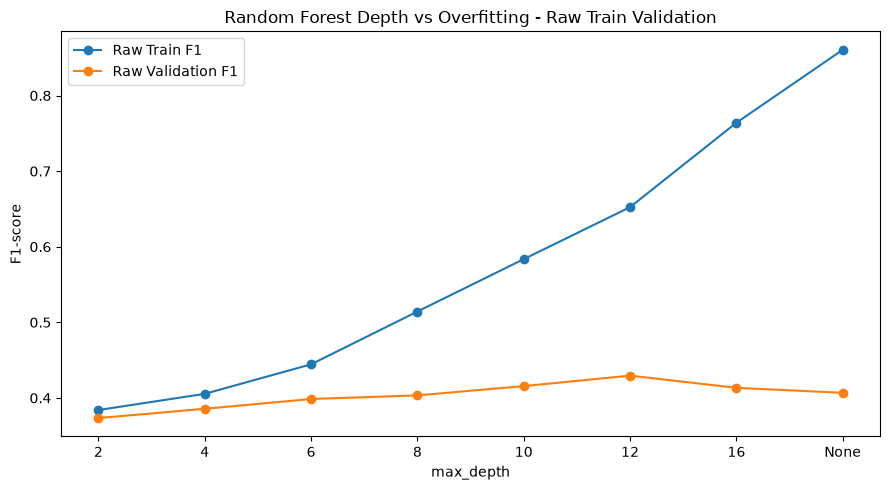

In [5]:
X_raw_tr, X_raw_val, y_raw_tr, y_raw_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_clean_tr, X_clean_val, y_clean_tr, y_clean_val = train_test_split(
    X_train_clean,
    y_train_clean,
    test_size=0.2,
    stratify=y_train_clean,
    random_state=RANDOM_STATE,
)

# 기존 criterion 비교 셀 호환용 변수. 이제 raw validation 기준을 기본으로 둔다.
X_tr, X_val, y_tr, y_val = X_raw_tr, X_raw_val, y_raw_tr, y_raw_val

depth_candidates = [2, 4, 6, 8, 10, 12, 16, None]

def run_depth_analysis(label, X_fit, X_validate, y_fit, y_validate):
    rows = []
    for depth in depth_candidates:
        model = RandomForestClassifier(
            n_estimators=200,
            criterion='gini',
            max_depth=depth,
            min_samples_leaf=3,
            max_features='sqrt',
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        model.fit(X_fit, y_fit)
        rows.append({
            'evaluation_set': label,
            'max_depth': 'None' if depth is None else depth,
            'train_f1': f1_score(y_fit, model.predict(X_fit)),
            'val_f1': f1_score(y_validate, model.predict(X_validate)),
            'train_accuracy': accuracy_score(y_fit, model.predict(X_fit)),
            'val_accuracy': accuracy_score(y_validate, model.predict(X_validate)),
        })
    return pd.DataFrame(rows)

depth_result_raw = run_depth_analysis('raw train validation', X_raw_tr, X_raw_val, y_raw_tr, y_raw_val)
depth_result_clean = run_depth_analysis('clean train validation', X_clean_tr, X_clean_val, y_clean_tr, y_clean_val)

# 기존 변수명은 raw validation 기준 결과를 가리키도록 유지한다.
depth_result = depth_result_raw
best_depth_row = depth_result_raw.loc[depth_result_raw['val_f1'].idxmax()]
best_depth_row_clean = depth_result_clean.loc[depth_result_clean['val_f1'].idxmax()]

print('Raw train validation split summary')
print(pd.DataFrame([
    {'set': 'raw depth train', 'rows': len(y_raw_tr), 'purchase_count': int(y_raw_tr.sum()), 'purchase_ratio': y_raw_tr.mean()},
    {'set': 'raw depth validation', 'rows': len(y_raw_val), 'purchase_count': int(y_raw_val.sum()), 'purchase_ratio': y_raw_val.mean()},
]).round(4).to_string(index=False))
print('\nRaw train validation depth result:')
print(depth_result_raw.round(4).drop(columns=['evaluation_set']).to_string(index=False))
print(f"\nRaw train validation F1 기준 최적 깊이: {best_depth_row['max_depth']} "
      f"(val_f1={best_depth_row['val_f1']:.4f}, train_f1={best_depth_row['train_f1']:.4f})")

print('\nClean train validation depth result 참고:')
print(depth_result_clean.round(4).drop(columns=['evaluation_set']).to_string(index=False))
print(f"\nClean train validation F1 기준 최적 깊이: {best_depth_row_clean['max_depth']} "
      f"(val_f1={best_depth_row_clean['val_f1']:.4f}, train_f1={best_depth_row_clean['train_f1']:.4f})")

plot_depth_raw = depth_result_raw.copy()
plot_depth_raw['depth_label'] = plot_depth_raw['max_depth'].astype(str)
plt.figure(figsize=(9, 5))
plt.plot(plot_depth_raw['depth_label'], plot_depth_raw['train_f1'], marker='o', label='Raw Train F1')
plt.plot(plot_depth_raw['depth_label'], plot_depth_raw['val_f1'], marker='o', label='Raw Validation F1')
plt.xlabel('max_depth')
plt.ylabel('F1-score')
plt.title('Random Forest Depth vs Overfitting - Raw Train Validation')
plt.legend()
plt.tight_layout()
plt.show()


### 깊이별 결과 해석

최종 test를 모델 선택에 반복 사용하지 않기 위해 train 내부에서 validation을 따로 만든다. `stratify`로 구매/비구매 비율을 유지했고, 깊이가 커질수록 train F1만 오르고 validation F1이 정체되면 과적합 신호로 해석한다.


### 2.2 criterion 비교

Random Forest의 `criterion`은 `gini` 외에 `entropy`, `log_loss`를 사용할 수 있다. 현재 설치된 scikit-learn에서 지원되는 criterion만 후보로 사용한다.


In [6]:
def supported_criteria(criteria):
    ok = []
    sample_X = X_train.head(100)
    sample_y = y_train.head(100)
    for criterion in criteria:
        try:
            RandomForestClassifier(
                n_estimators=5,
                criterion=criterion,
                random_state=RANDOM_STATE,
            ).fit(sample_X, sample_y)
            ok.append(criterion)
        except ValueError:
            pass
    return ok

criteria = supported_criteria(['gini', 'entropy', 'log_loss'])
criterion_rows = []
for criterion in criteria:
    model = RandomForestClassifier(
        n_estimators=200,
        criterion=criterion,
        max_depth=best_depth_row['max_depth'] if best_depth_row['max_depth'] != 'None' else None,
        min_samples_leaf=3,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    criterion_rows.append(evaluate_model(criterion, model, X_val, y_val))

criterion_result = pd.DataFrame(criterion_rows).sort_values('f1', ascending=False)
print(f'Criterion candidates: {criteria}')
criterion_result.round(4)


Criterion candidates: ['gini', 'entropy', 'log_loss']


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,gini,0.7307,0.3209,0.6492,0.4295,0.7673,0.3520
1,entropy,0.7204,0.3132,0.6623,0.4253,0.7678,0.3547
2,log_loss,0.7204,0.3132,0.6623,0.4253,0.7678,0.3547


### criterion 비교 해석

`criterion`은 각 트리가 분기를 고를 때 사용하는 기준이다. 현재 scikit-learn 환경에서 실제 지원되는 후보만 비교해 튜닝 후보에 반영한다.


### 2.3 하이퍼파라미터 튜닝

F1을 기준으로 `criterion`, `max_depth`, `min_samples_leaf`, `min_samples_split`, `max_features`, `n_estimators`를 탐색한다.

F1을 튜닝 기준으로 둔 이유는 이번 문제가 단순히 전체 정답률을 높이는 문제가 아니기 때문이다. 구매자는 소수 클래스이므로 실제 구매자를 놓치지 않는 Recall이 중요하지만, 모든 세션을 구매라고 찍으면 Precision이 무너진다. F1은 이 두 값을 함께 벌점화하므로, 구매 후보를 넓게 잡으면서도 무의미한 오탐만 늘리는 모델을 피하는 기준으로 쓸 수 있다.


In [7]:
param_distributions = {
    'n_estimators': [150, 250, 350],
    'criterion': criteria,
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 10, 30, 50],
    'min_samples_leaf': [1, 3, 5, 10, 20],
    'max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
summary_cols = [
    'rank_test_score', 'mean_test_score', 'std_test_score', 'mean_train_score',
    'param_n_estimators', 'param_criterion', 'param_max_depth',
    'param_min_samples_leaf', 'param_min_samples_split', 'param_max_features',
]


def run_rf_search(scoring, label):
    search = RandomizedSearchCV(
        estimator=RandomForestClassifier(
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        param_distributions=param_distributions,
        n_iter=60,
        scoring=scoring,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    result_df = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
    return search, result_df


def tuning_summary_row(label, search):
    return {
        'target': label,
        'best_cv_score': search.best_score_,
        **search.best_params_,
    }


def top_tuning_rows(result_df, n=5):
    rename = {
        'rank_test_score': 'rank',
        'mean_test_score': 'cv',
        'std_test_score': 'std',
        'mean_train_score': 'train',
        'param_n_estimators': 'trees',
        'param_criterion': 'criterion',
        'param_max_depth': 'depth',
        'param_min_samples_leaf': 'leaf',
        'param_min_samples_split': 'split',
        'param_max_features': 'features',
    }
    return result_df[summary_cols].head(n).round(4).rename(columns=rename)


def display_side_by_side(title_to_df):
    style = """
    <style>
    .rf-side-by-side {
        display: grid;
        grid-template-columns: repeat(2, minmax(0, 1fr));
        gap: 16px;
        max-width: 100%;
    }
    .rf-table-block {
        min-width: 0;
        overflow-x: auto;
    }
    .rf-table-block h4 {
        margin: 0 0 6px 0;
    }
    .rf-table-block table {
        border-collapse: collapse;
        font-size: 11px;
        line-height: 1.25;
        white-space: nowrap;
    }
    .rf-table-block th, .rf-table-block td {
        padding: 3px 6px;
    }
    @media (max-width: 900px) {
        .rf-side-by-side { grid-template-columns: 1fr; }
    }
    </style>
    """
    blocks = []
    for title, df in title_to_df.items():
        blocks.append(
            '<div class="rf-table-block">'
            f'<h4>{title}</h4>'
            + df.to_html(index=False)
            + '</div>'
        )
    display(HTML(style + '<div class="rf-side-by-side">' + ''.join(blocks) + '</div>'))


f1_search, f1_cv_result = run_rf_search('f1', 'F1')
precision_search, precision_cv_result = run_rf_search('precision', 'Precision')

tuning_summary = pd.DataFrame([
    tuning_summary_row('F1', f1_search),
    tuning_summary_row('Precision', precision_search),
])

display(tuning_summary.round(4))
display_side_by_side({
    'Top 5 CV results - F1': top_tuning_rows(f1_cv_result),
    'Top 5 CV results - Precision': top_tuning_rows(precision_cv_result),
})


,target,best_cv_score,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,criterion
0,F1,0.4336,150,50,5,sqrt,None,log_loss
1,Precision,0.3623,250,2,3,log2,None,entropy


rank,cv,std,train,trees,criterion,depth,leaf,split,features
1,0.4336,0.0163,0.5847,150,log_loss,NaN,5,50,sqrt
2,0.4325,0.0146,0.6044,250,entropy,NaN,10,10,log2
3,0.4320,0.0137,0.6163,350,entropy,NaN,1,50,sqrt
4,0.4317,0.0185,0.6456,150,gini,12.0,3,10,sqrt
5,0.4313,0.0138,0.6324,250,gini,12.0,5,10,sqrt
rank,cv,std,train,trees,criterion,depth,leaf,split,features
1,0.3623,0.0202,0.7384,250,entropy,NaN,3,2,log2
2,0.3575,0.0263,0.7248,350,gini,NaN,3,2,log2
3,0.3297,0.0165,0.5178,350,gini,NaN,1,30,log2
4,0.3254,0.0189,0.4815,150,gini,12.0,3,10,sqrt


### 튜닝 결과 해석

`RandomizedSearchCV`는 전체 조합을 모두 계산하지 않고 일부 조합을 무작위로 탐색한다. 여기서는 F1 기준 모델과 Precision 기준 모델을 따로 찾아, 구매 후보를 넓게 잡는 모델과 더 보수적인 모델을 비교한다.


### 2.4 최종 모델 평가

튜닝된 모델을 극단값 제거 없이 raw train 전체에 학습한 결과를 메인 test 성능으로 확인한다. IQR 제거 데이터는 비교용으로만 함께 출력한다.


In [8]:
def make_default_rf():
    return RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def prediction_bundle(model, X_eval):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    return y_pred, y_prob


def evaluation_set_summary():
    return pd.DataFrame([
        {'set': 'raw test', 'rows': len(y_test), 'purchase_count': int(y_test.sum()), 'purchase_ratio': y_test.mean()},
        {'set': 'clean test', 'rows': len(y_test_clean), 'purchase_count': int(y_test_clean.sum()), 'purchase_ratio': y_test_clean.mean()},
    ])


def evaluate_model_table(model_specs, X_eval, y_eval, evaluation_set):
    table = pd.DataFrame([
        evaluate_model(name, model, X_eval, y_eval)
        for name, model in model_specs
    ])
    table.insert(1, 'evaluation_set', evaluation_set)
    return table


default_model = make_default_rf()
default_model.fit(X_train, y_train)

best_f1_model = f1_search.best_estimator_
best_precision_model = precision_search.best_estimator_

# 기존 분석 셀과 호환되도록 F1 기준 모델을 기본 tuned 모델로 둔다.
best_model = best_f1_model

y_pred_f1, y_prob_f1 = prediction_bundle(best_f1_model, X_test_clean)
y_pred_precision, y_prob_precision = prediction_bundle(best_precision_model, X_test_clean)
y_pred_f1_raw, y_prob_f1_raw = prediction_bundle(best_f1_model, X_test)
y_pred_precision_raw, y_prob_precision_raw = prediction_bundle(best_precision_model, X_test)

# 기존 변수명은 raw test의 F1 기준 tuned model을 가리키도록 유지한다.
y_pred = y_pred_f1_raw
y_prob = y_prob_f1_raw

model_specs = [
    ('Random Forest default', default_model),
    ('Random Forest tuned by F1', best_f1_model),
    ('Random Forest tuned by Precision', best_precision_model),
]

metrics_clean = evaluate_model_table(model_specs, X_test_clean, y_test_clean, 'clean test')
metrics_raw = evaluate_model_table(model_specs, X_test, y_test, 'raw test')

# 기존 변수명은 raw test 기준 표를 가리키도록 유지한다.
metrics = metrics_raw

display(evaluation_set_summary().round(4))
display(metrics_raw.round(4))


,set,rows,purchase_count,purchase_ratio
0,raw test,2441,382,0.1565
1,clean test,1628,252,0.1548


,model,evaluation_set,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest default,raw test,0.8193,0.4026,0.3194,0.3562,0.7770,0.3556
1,Random Forest tuned by F1,raw test,0.7284,0.3224,0.6675,0.4348,0.7871,0.3726
2,Random Forest tuned by Precision,raw test,0.7825,0.3576,0.4895,0.4133,0.7803,0.3659


### 최종 모델 평가 해석

기본 RF, F1 튜닝 RF, Precision 튜닝 RF를 같은 raw test 기준으로 비교한다. clean test는 IQR 제거가 결과를 크게 바꾸는지 확인하는 보조 비교이며, 메인 해석은 raw test 성능을 기준으로 한다.


### 2.5 혼동 행렬

F1 튜닝 모델이 실제 구매자를 더 많이 잡는지 혼동 행렬로 확인한다. ROC/PR 곡선과 상세 classification report는 상세 지표 섹션에서 함께 확인한다.


Raw test confusion matrices
F1 tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1523,536
Actual Purchase,127,255


Precision tuned confusion matrix


,Pred No Purchase,Pred Purchase
Actual No Purchase,1723,336
Actual Purchase,195,187


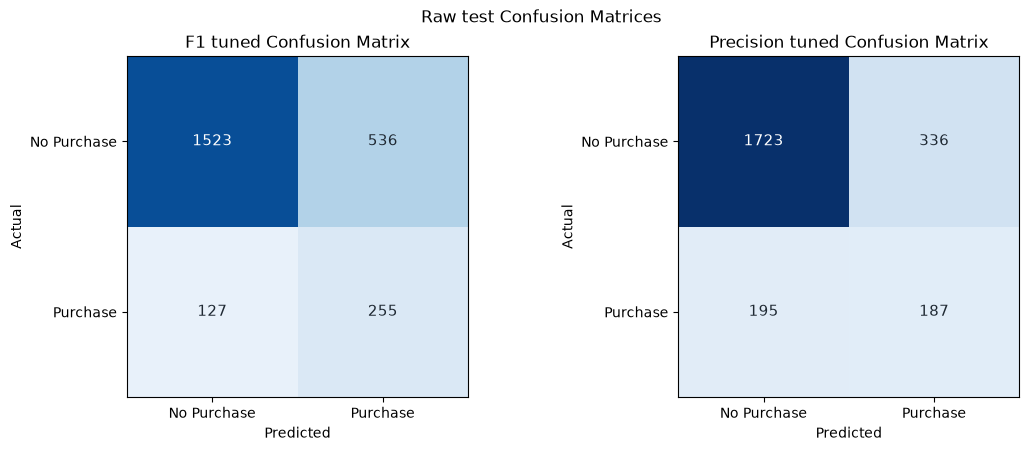

In [9]:
def make_model_outputs(f1_pred, f1_prob, precision_pred, precision_prob):
    return {
        'F1 tuned': {
            'model': best_f1_model,
            'y_pred': f1_pred,
            'y_prob': f1_prob,
        },
        'Precision tuned': {
            'model': best_precision_model,
            'y_pred': precision_pred,
            'y_prob': precision_prob,
        },
    }


model_outputs_clean = make_model_outputs(y_pred_f1, y_prob_f1, y_pred_precision, y_prob_precision)
model_outputs_raw = make_model_outputs(y_pred_f1_raw, y_prob_f1_raw, y_pred_precision_raw, y_prob_precision_raw)

# 이후 feature importance 셀과의 호환을 위해 모델 출력 기본값은 raw test 기준으로 둔다.
model_outputs = model_outputs_raw


def display_confusion_tables(label, outputs, y_eval):
    print(f'{label} confusion matrices')
    for name, output in outputs.items():
        cm = confusion_matrix(y_eval, output['y_pred'])
        confusion = pd.DataFrame(
            cm,
            index=['Actual No Purchase', 'Actual Purchase'],
            columns=['Pred No Purchase', 'Pred Purchase'],
        )
        print(f'{name} confusion matrix')
        display(confusion)


def plot_confusion_matrices(label, outputs, y_eval):
    matrices = {
        name: confusion_matrix(y_eval, output['y_pred'])
        for name, output in outputs.items()
    }
    max_count = max(cm.max() for cm in matrices.values())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), constrained_layout=True)
    fig.suptitle(f'{label} Confusion Matrices')
    for ax, (name, cm) in zip(axes, matrices.items()):
        ax.imshow(cm, cmap='Blues', vmin=0, vmax=max_count)
        ax.set_xticks([0, 1], ['No Purchase', 'Purchase'])
        ax.set_yticks([0, 1], ['No Purchase', 'Purchase'])
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                value = cm[row, col]
                text_color = 'white' if value > max_count * 0.55 else '#1f2933'
                ax.text(col, row, str(value), ha='center', va='center', color=text_color, fontsize=11)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(f'{name} Confusion Matrix')
    plt.show()
    return matrices


display_confusion_tables('Raw test', model_outputs_raw, y_test)
confusion_matrices_raw = plot_confusion_matrices('Raw test', model_outputs_raw, y_test)
# 기존 변수명은 raw test 기준 혼동행렬을 가리키도록 유지한다.
confusion_matrices = confusion_matrices_raw


### 2.6 변수 중요도

혼동 행렬로 성능을 본 뒤, 같은 raw test 기준 모델들의 변수 중요도를 확인한다.


model,feature,importance
F1 tuned,ExitRates,0.1565
F1 tuned,ProductRelated_Duration,0.0986
F1 tuned,total_duration,0.0920
F1 tuned,BounceRates,0.0770
F1 tuned,avg_time_per_product,0.0733
F1 tuned,total_pages,0.0590
F1 tuned,ProductRelated,0.0578
F1 tuned,Administrative_Duration,0.0471
F1 tuned,Administrative,0.0464
F1 tuned,bounce_exit_ratio,0.0439


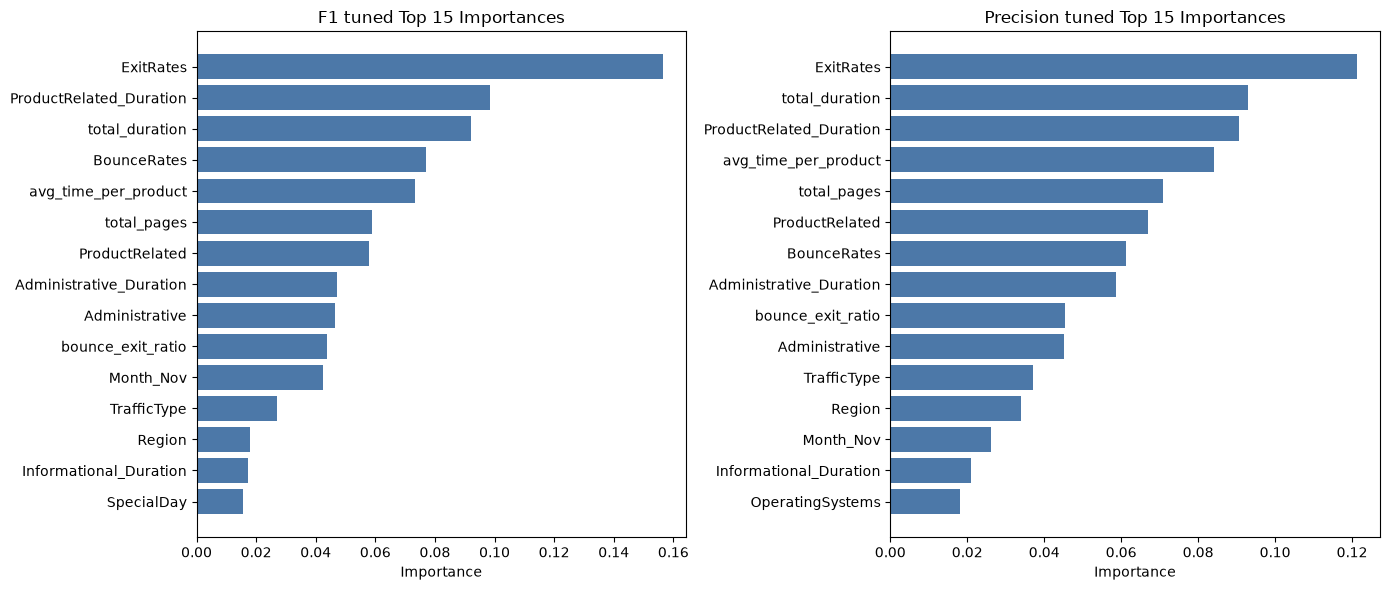

In [9]:
def feature_importance_table(name, model, columns):
    return (
        pd.DataFrame({
            'model': name,
            'feature': columns,
            'importance': model.feature_importances_,
        })
        .sort_values('importance', ascending=False)
    )


def display_importance_tables(outputs, columns):
    tables = [
        feature_importance_table(name, output['model'], columns)
        for name, output in outputs.items()
    ]
    display_side_by_side({
        table['model'].iloc[0]: table.head(15).round(4)
        for table in tables
    })
    return tables


def plot_importance_tables(importance_tables, figsize=(14, 6), color='#4c78a8'):
    fig, axes = plt.subplots(1, len(importance_tables), figsize=figsize)
    for ax, importance in zip(axes, importance_tables):
        name = importance['model'].iloc[0]
        plot_df = importance.head(15).sort_values('importance')
        ax.barh(plot_df['feature'], plot_df['importance'], color=color)
        ax.set_title(f'{name} Top 15 Importances')
        ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()


importance_tables = display_importance_tables(model_outputs, X_train.columns)
plot_importance_tables(importance_tables)

feature_importance = importance_tables[0].drop(columns=['model'])


### 변수 중요도 해석

혼동 행렬은 실제 구매자를 얼마나 놓쳤는지와 비구매를 구매로 얼마나 잘못 예측했는지를 보여준다. 변수 중요도는 Random Forest가 어떤 행동 변수에 많이 의존했는지 확인하는 해석 근거로 사용한다.


## 3. RF + K-Means 연계 실험

K-Means 군집 정보를 Random Forest 입력 변수로 붙였을 때 예측 성능이 달라지는지 확인한다.

---


### 3.1 K-Means 군집 변수를 활용한 RF 비교

이 섹션에서는 `models/clustering/`에서 만든 K-Means 군집 정보를 RF 입력 변수로 추가해 성능 변화를 비교한다. 여기서 말하는 추가는 두 모델의 예측값을 평균내거나 투표로 섞는 방식이 아니라, K-Means가 만든 cluster label과 중심 거리 정보를 RF의 새로운 입력 변수로 넣는 방식이다.

진행 방식은 다음과 같다. 먼저 RF의 기존 `X_train`, `X_test`, `y_train`, `y_test` split은 그대로 둔다. K-Means 입력은 `models/clustering/csv/X_train_knn.csv`, `X_test_knn.csv`의 11개 군집용 변수를 사용한다. 단, 평가 누수를 막기 위해 `cluster_assignment.csv`처럼 train/test를 합쳐 만든 결과는 RF 입력 변수로 쓰지 않는다. 대신 clustering 폴더의 train 데이터에만 `log1p`와 `StandardScaler`, `KMeans(K=3)`를 fit하고 test 데이터는 같은 scaler와 K-Means 중심으로 `predict`와 `transform`만 수행한다.

실제로 추가된 변수는 두 종류다. 첫 번째는 군집 라벨 one-hot이다. 예를 들어 어떤 세션이 cluster 2에 속하면 `rf_cluster_2=1`, `rf_cluster_0=0`, `rf_cluster_1=0`처럼 표시된다. 두 번째는 각 세션이 세 군집 중심에서 얼마나 떨어져 있는지를 나타내는 `rf_cluster_dist_0`, `rf_cluster_dist_1`, `rf_cluster_dist_2`다. label은 "어느 군집인가"를 알려주고, distance는 "세 군집 중심과 각각 얼마나 가까운가"를 알려준다.

비교 모델은 세 가지다. 첫째, 기존 F1 tuned RF. 둘째, K-Means 군집 라벨을 `rf_cluster_0`, `rf_cluster_1`, `rf_cluster_2` one-hot 컬럼으로 추가한 RF. 셋째, one-hot에 더해 `rf_cluster_dist_0~2`까지 추가한 RF다. 세 모델은 같은 F1 tuned RF 하이퍼파라미터를 사용하므로, 차이는 군집 변수 추가 여부에서 온다.


#### 3.1.1 K-Means 입력 데이터 검증

RF의 train/test split과 clustering 폴더의 train/test split이 같은 행 순서인지 먼저 확인한다. 이 검증이 깨지면 군집 라벨을 붙였을 때 다른 방문자의 정보가 섞일 수 있다.


In [10]:
KMEANS_K = 3

def find_clustering_csv_dir():
    required = ['X_train_knn.csv', 'X_test_knn.csv', 'y_train_knn.csv', 'y_test_knn.csv']
    candidates = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidates.extend([
            base / 'csv',
            base / 'clustering' / 'csv',
            base / 'models' / 'clustering' / 'csv',
            base / 'shopper-prediction' / 'models' / 'clustering' / 'csv',
        ])
    for base in candidates:
        if all((base / name).exists() for name in required):
            return base
    raise FileNotFoundError('clustering 폴더의 X/y train/test CSV 파일을 찾지 못했습니다.')

CLUSTERING_CSV_DIR = find_clustering_csv_dir()
X_train_kmeans_raw = pd.read_csv(CLUSTERING_CSV_DIR / 'X_train_knn.csv')
X_test_kmeans_raw = pd.read_csv(CLUSTERING_CSV_DIR / 'X_test_knn.csv')
y_train_kmeans_check = pd.read_csv(CLUSTERING_CSV_DIR / 'y_train_knn.csv').iloc[:, 0].astype(int).reset_index(drop=True)
y_test_kmeans_check = pd.read_csv(CLUSTERING_CSV_DIR / 'y_test_knn.csv').iloc[:, 0].astype(int).reset_index(drop=True)

if len(X_train_kmeans_raw) != len(X_train) or len(X_test_kmeans_raw) != len(X_test):
    raise ValueError('clustering train/test 행 수가 RF train/test split과 일치하지 않습니다.')
if not np.array_equal(y_train_kmeans_check.values, y_train.values):
    raise ValueError('clustering y_train이 RF y_train과 일치하지 않습니다.')
if not np.array_equal(y_test_kmeans_check.values, y_test.values):
    raise ValueError('clustering y_test가 RF y_test와 일치하지 않습니다.')


#### 3.1.2 train-only K-Means 군집 생성

K-Means는 거리 기반 모델이므로 `log1p`와 `StandardScaler`를 적용한다. scaler와 K-Means는 train에만 fit하고, test에는 같은 변환과 중심을 적용해 누수를 막는다.


In [10]:
KMEANS_FEATURES = list(X_train_kmeans_raw.columns)
KMEANS_LOG_COLS = [
    col for col in [
        'Administrative', 'Administrative_Duration',
        'Informational', 'Informational_Duration',
        'ProductRelated', 'ProductRelated_Duration',
        'BounceRates', 'ExitRates', 'SpecialDay',
    ]
    if col in KMEANS_FEATURES
]

X_train_kmeans_log = X_train_kmeans_raw[KMEANS_FEATURES].copy()
X_test_kmeans_log = X_test_kmeans_raw[KMEANS_FEATURES].copy()
X_train_kmeans_log[KMEANS_LOG_COLS] = np.log1p(X_train_kmeans_log[KMEANS_LOG_COLS])
X_test_kmeans_log[KMEANS_LOG_COLS] = np.log1p(X_test_kmeans_log[KMEANS_LOG_COLS])

kmeans_scaler = StandardScaler().fit(X_train_kmeans_log)
X_train_kmeans_scaled = kmeans_scaler.transform(X_train_kmeans_log)
X_test_kmeans_scaled = kmeans_scaler.transform(X_test_kmeans_log)

kmeans = KMeans(n_clusters=KMEANS_K, random_state=RANDOM_STATE, n_init=10)
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=RuntimeWarning, module='sklearn')
    train_cluster_labels = kmeans.fit_predict(X_train_kmeans_scaled)
    test_cluster_labels = kmeans.predict(X_test_kmeans_scaled)
    train_cluster_distances = kmeans.transform(X_train_kmeans_scaled)
    test_cluster_distances = kmeans.transform(X_test_kmeans_scaled)

cluster_profile = (
    pd.DataFrame({'cluster': train_cluster_labels, 'Revenue': y_train})
    .groupby('cluster')
    .agg(rows=('Revenue', 'size'), purchase_count=('Revenue', 'sum'), purchase_ratio=('Revenue', 'mean'))
    .reset_index()
    .sort_values('cluster')
)

print('K-Means source directory')
print(CLUSTERING_CSV_DIR)
print('\nK-Means train-only clustering profile')
print(cluster_profile.round(4).to_string(index=False))
print('\nK-Means behavior feature columns')
print(KMEANS_FEATURES)


K-Means source directory
/Users/hyunkim/2026_2/datamining/shopper-prediction/models/clustering/csv
\nK-Means train-only clustering profile
 cluster  rows  purchase_count  purchase_ratio
       0  7207            1093          0.1517
       1  1851             430          0.2323
       2   706               3          0.0042
\nK-Means behavior feature columns
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay', 'Weekend', 'is_new_visitor']


#### 3.1.3 군집 feature를 RF 입력에 추가

군집 label은 one-hot 변수로 바꾸고, 중심까지의 거리는 별도 연속형 변수로 추가한다. 따라서 비교군은 기존 RF, label one-hot 추가 RF, label one-hot과 거리까지 추가한 RF 세 가지다.


In [10]:
cluster_columns = ['rf_cluster_0', 'rf_cluster_1', 'rf_cluster_2']
distance_columns = ['rf_cluster_dist_0', 'rf_cluster_dist_1', 'rf_cluster_dist_2']


def make_cluster_feature_frame(labels, distances=None, include_distances=False):
    label_series = pd.Series(labels, name='rf_cluster')
    one_hot = pd.get_dummies(label_series, prefix='rf_cluster').astype(int)
    one_hot = one_hot.reindex(columns=cluster_columns, fill_value=0)
    if not include_distances:
        return one_hot.reset_index(drop=True)

    distance_frame = pd.DataFrame(distances, columns=distance_columns)
    return pd.concat(
        [one_hot.reset_index(drop=True), distance_frame.reset_index(drop=True)],
        axis=1,
    )


def append_cluster_features(X_base, cluster_features):
    return pd.concat(
        [X_base.reset_index(drop=True), cluster_features],
        axis=1,
    )


def feature_matrix_shapes():
    return pd.DataFrame([
        {'matrix': 'baseline', 'train_columns': X_train.shape[1], 'test_columns': X_test.shape[1]},
        {'matrix': 'cluster one-hot', 'train_columns': X_train_cluster.shape[1], 'test_columns': X_test_cluster.shape[1]},
        {'matrix': 'cluster one-hot + distances', 'train_columns': X_train_cluster_distance.shape[1], 'test_columns': X_test_cluster_distance.shape[1]},
    ])


train_cluster_features = make_cluster_feature_frame(train_cluster_labels)
test_cluster_features = make_cluster_feature_frame(test_cluster_labels)
train_cluster_distance_features = make_cluster_feature_frame(
    train_cluster_labels,
    train_cluster_distances,
    include_distances=True,
)
test_cluster_distance_features = make_cluster_feature_frame(
    test_cluster_labels,
    test_cluster_distances,
    include_distances=True,
)

X_train_cluster = append_cluster_features(X_train, train_cluster_features)
X_test_cluster = append_cluster_features(X_test, test_cluster_features)
X_train_cluster_distance = append_cluster_features(X_train, train_cluster_distance_features)
X_test_cluster_distance = append_cluster_features(X_test, test_cluster_distance_features)

print('Feature matrix shapes')
print(feature_matrix_shapes().to_string(index=False))


Feature matrix shapes
                     matrix  train_columns  test_columns
                   baseline             31            31
            cluster one-hot             34            34
cluster one-hot + distances             37            37


#### 3.1.4 기준 RF와 군집 feature RF 성능 비교

세 모델은 같은 F1 튜닝 하이퍼파라미터를 사용한다. 따라서 성능 차이는 군집 기반 변수를 추가했는지에서 온다.


In [10]:
def make_f1_tuned_rf():
    params = f1_search.best_params_.copy()
    return RandomForestClassifier(
        **params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

cluster_model = make_f1_tuned_rf()
cluster_model.fit(X_train_cluster, y_train)

cluster_distance_model = make_f1_tuned_rf()
cluster_distance_model.fit(X_train_cluster_distance, y_train)

fusion_metrics = pd.DataFrame([
    evaluate_model('RF baseline tuned by F1', best_f1_model, X_test, y_test),
    evaluate_model('RF + KMeans one-hot', cluster_model, X_test_cluster, y_test),
    evaluate_model('RF + KMeans one-hot + distances', cluster_distance_model, X_test_cluster_distance, y_test),
])

print('\nRaw test fusion metrics:')
print(fusion_metrics.round(4).to_string(index=False))


\nRaw test fusion metrics:
                          model  accuracy  precision  recall     f1  roc_auc  pr_auc
        RF baseline tuned by F1    0.7284     0.3224  0.6675 0.4348   0.7871  0.3726
            RF + KMeans one-hot    0.7272     0.3243  0.6859 0.4403   0.7897  0.3701
RF + KMeans one-hot + distances    0.7239     0.3166  0.6597 0.4278   0.7844  0.3633


#### 3.1.5 군집 feature 중요도 확인

성능 지표뿐 아니라 `feature_importances_`에서 군집 파생 변수가 실제로 사용됐는지도 확인한다. distance 변수는 중요도가 커 보일 수 있으므로, 반드시 성능 개선 여부와 함께 해석한다.


\nRF baseline tuned by F1 top 15 feature importance


,model,feature,importance
0,RF baseline tuned by F1,ExitRates,0.1565
1,RF baseline tuned by F1,ProductRelated_Duration,0.0986
2,RF baseline tuned by F1,total_duration,0.0920
3,RF baseline tuned by F1,BounceRates,0.0770
4,RF baseline tuned by F1,avg_time_per_product,0.0733
5,RF baseline tuned by F1,total_pages,0.0590
6,RF baseline tuned by F1,ProductRelated,0.0578
7,RF baseline tuned by F1,Administrative_Duration,0.0471
8,RF baseline tuned by F1,Administrative,0.0464
9,RF baseline tuned by F1,bounce_exit_ratio,0.0439


\nRF + KMeans one-hot top 15 feature importance


,model,feature,importance
0,RF + KMeans one-hot,ExitRates,0.1523
1,RF + KMeans one-hot,ProductRelated_Duration,0.0909
2,RF + KMeans one-hot,total_duration,0.0842
3,RF + KMeans one-hot,avg_time_per_product,0.0789
4,RF + KMeans one-hot,BounceRates,0.0764
5,RF + KMeans one-hot,ProductRelated,0.0606
6,RF + KMeans one-hot,total_pages,0.0593
7,RF + KMeans one-hot,Administrative_Duration,0.0475
8,RF + KMeans one-hot,Administrative,0.0442
9,RF + KMeans one-hot,Month_Nov,0.0412


\nRF + KMeans one-hot + distances top 15 feature importance


,model,feature,importance
0,RF + KMeans one-hot + distances,ExitRates,0.1309
1,RF + KMeans one-hot + distances,rf_cluster_dist_2,0.1074
2,RF + KMeans one-hot + distances,ProductRelated_Duration,0.0792
3,RF + KMeans one-hot + distances,total_duration,0.0662
4,RF + KMeans one-hot + distances,avg_time_per_product,0.0612
5,RF + KMeans one-hot + distances,rf_cluster_dist_1,0.0559
6,RF + KMeans one-hot + distances,BounceRates,0.0523
7,RF + KMeans one-hot + distances,total_pages,0.0494
8,RF + KMeans one-hot + distances,ProductRelated,0.0465
9,RF + KMeans one-hot + distances,rf_cluster_dist_0,0.0456


\nCluster-derived feature importance


,model,feature,importance
54,RF + KMeans one-hot,rf_cluster_2,0.0086
58,RF + KMeans one-hot,rf_cluster_0,0.0043
59,RF + KMeans one-hot,rf_cluster_1,0.0038
66,RF + KMeans one-hot + distances,rf_cluster_dist_2,0.1074
70,RF + KMeans one-hot + distances,rf_cluster_dist_1,0.0559
74,RF + KMeans one-hot + distances,rf_cluster_dist_0,0.0456
92,RF + KMeans one-hot + distances,rf_cluster_2,0.0038
93,RF + KMeans one-hot + distances,rf_cluster_0,0.0036
99,RF + KMeans one-hot + distances,rf_cluster_1,0.0011


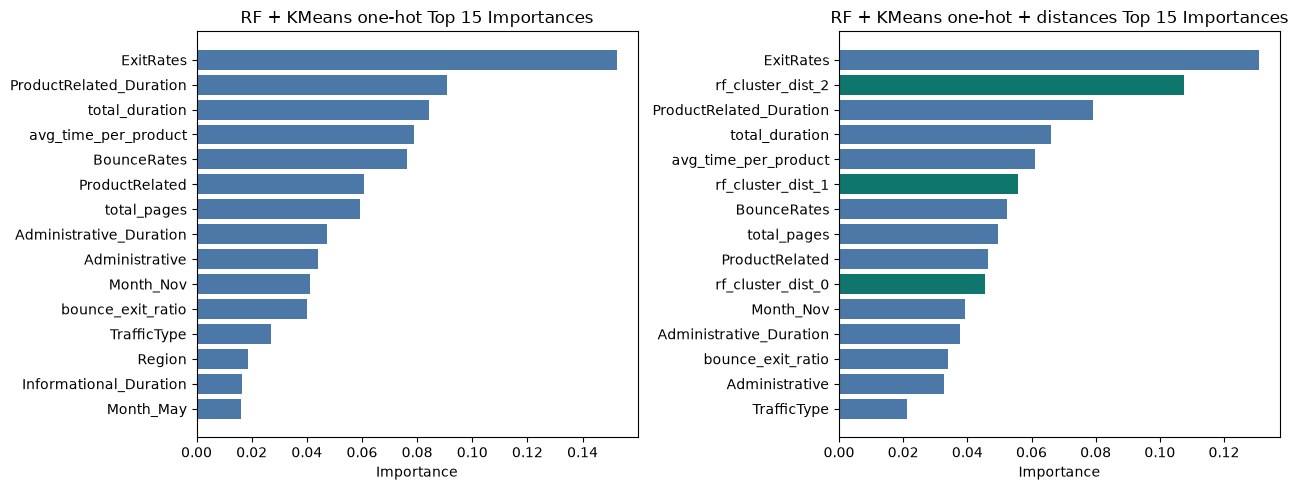

In [10]:
def make_fusion_outputs():
    return {
        'RF baseline tuned by F1': {
            'model': best_f1_model,
            'X_eval': X_test,
            'feature_names': list(X_train.columns),
        },
        'RF + KMeans one-hot': {
            'model': cluster_model,
            'X_eval': X_test_cluster,
            'feature_names': list(X_train_cluster.columns),
        },
        'RF + KMeans one-hot + distances': {
            'model': cluster_distance_model,
            'X_eval': X_test_cluster_distance,
            'feature_names': list(X_train_cluster_distance.columns),
        },
    }


def display_fusion_importances(outputs):
    tables = []
    for name, output in outputs.items():
        importance = (
            feature_importance_table(name, output['model'], output['feature_names'])
            .reset_index(drop=True)
        )
        tables.append(importance)
        print(f'\n{name} top 15 feature importance')
        display(importance.head(15).round(4))
    return tables


def cluster_importance_rows(fusion_importance):
    return fusion_importance[
        fusion_importance['feature'].str.startswith('rf_cluster')
    ].sort_values(['model', 'importance'], ascending=[True, False])


def plot_cluster_feature_importances(plot_models):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (name, model, columns) in zip(axes, plot_models):
        plot_df = (
            pd.DataFrame({'feature': columns, 'importance': model.feature_importances_})
            .sort_values('importance', ascending=False)
            .head(15)
            .sort_values('importance')
        )
        colors = ['#0f766e' if feature.startswith('rf_cluster') else '#4c78a8' for feature in plot_df['feature']]
        ax.barh(plot_df['feature'], plot_df['importance'], color=colors)
        ax.set_title(f'{name} Top 15 Importances')
        ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()


fusion_outputs = make_fusion_outputs()
fusion_importance_tables = display_fusion_importances(fusion_outputs)
fusion_importance = pd.concat(fusion_importance_tables, ignore_index=True)
cluster_feature_importance = cluster_importance_rows(fusion_importance)

print('\nCluster-derived feature importance')
display(cluster_feature_importance.round(4))

plot_models = [
    ('RF + KMeans one-hot', cluster_model, X_train_cluster.columns),
    ('RF + KMeans one-hot + distances', cluster_distance_model, X_train_cluster_distance.columns),
]
plot_cluster_feature_importances(plot_models)


#### 3.1.6 K-Means 군집 변수 해석

K-Means train-only profile은 `models/clustering/csv/X_train_knn.csv`만으로 다시 학습한 결과다. clustering 보고서의 변수 체계와 전처리 방식은 유지하되, RF 평가 누수를 피하려고 `cluster_assignment.csv`처럼 전체 train/test를 합쳐 만든 결과는 사용하지 않았다. test는 train에서 학습된 scaler와 K-Means 중심에 대해 `predict`와 `transform`만 수행했다.

군집 변수를 붙인 목적은 RF가 개별 변수와 함께 "이 세션이 clustering 분석에서 정의한 행동 유형 중 어디에 가까운지"를 반영하게 하는 것이다. 성능 비교는 기존 F1 tuned RF, `RF + KMeans one-hot`, `RF + KMeans one-hot + distances` 세 모델을 같은 raw test split에서 수행한다.

해석은 지표 기준으로 한다. one-hot 모델은 기준 모델보다 F1과 Recall을 조금 올렸다. distance 변수는 중요도는 커 보이지만 실제 F1과 Recall이 one-hot만 쓴 모델보다 낮으므로, 복잡도를 늘릴 근거로 보기는 어렵다.


## 4. 상세 지표 및 참고 출력

ROC/PR 곡선, clean test 민감도 분석, 상세 classification report를 모아 둔다.

---


### 4.1 ROC/PR 곡선 및 상세 리포트

ROC/PR 곡선과 clean test 민감도 분석, classification report는 참고 출력으로 둔다.


,model,evaluation_set,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest default,clean test,0.8206,0.3851,0.2659,0.3146,0.7516,0.3271
1,Random Forest tuned by F1,clean test,0.7236,0.3089,0.6349,0.4156,0.7689,0.3619
2,Random Forest tuned by Precision,clean test,0.7862,0.3500,0.4444,0.3916,0.7586,0.3494


Classification report - F1 tuned model (clean test):
              precision    recall  f1-score   support

 No Purchase       0.92      0.74      0.82      1376
    Purchase       0.31      0.63      0.42       252

    accuracy                           0.72      1628
   macro avg       0.61      0.69      0.62      1628
weighted avg       0.82      0.72      0.76      1628

Classification report - F1 tuned model (raw test):
              precision    recall  f1-score   support

 No Purchase       0.92      0.74      0.82      2059
    Purchase       0.32      0.67      0.43       382

    accuracy                           0.73      2441
   macro avg       0.62      0.70      0.63      2441
weighted avg       0.83      0.73      0.76      2441

Best F1-tuned params:
{'n_estimators': 150, 'min_samples_split': 50, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'log_loss'}

Classification report - Precision tuned model (clean test):
              precisi

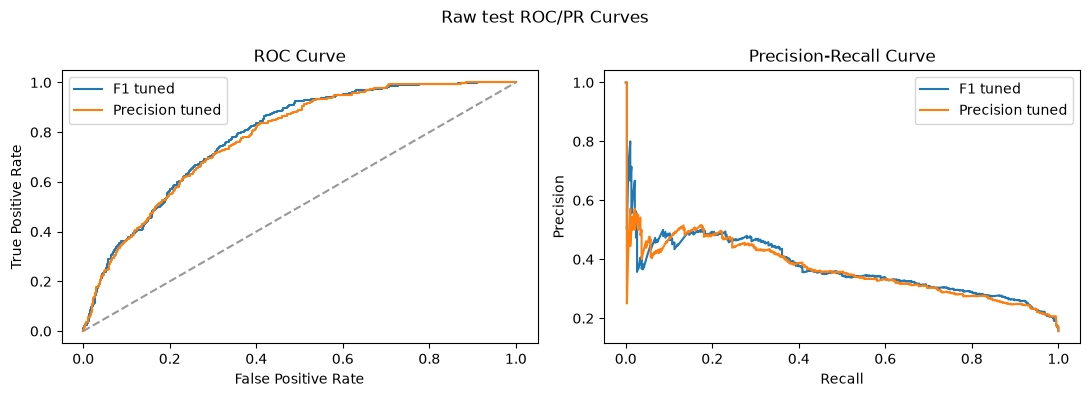

In [9]:
def plot_roc_pr_curves(label, outputs, y_eval):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(label)
    for name, output in outputs.items():
        fpr, tpr, _ = roc_curve(y_eval, output['y_prob'])
        precision, recall, _ = precision_recall_curve(y_eval, output['y_prob'])
        axes[0].plot(fpr, tpr, label=name)
        axes[1].plot(recall, precision, label=name)
    axes[0].plot([0, 1], [0, 1], linestyle='--', color='#999999')
    axes[0].set_title('ROC Curve')
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].legend()
    axes[1].set_title('Precision-Recall Curve')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


display(metrics_clean.round(4))

print('Classification report - F1 tuned model (clean test):')
print(classification_report(y_test_clean, y_pred_f1, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('\nClassification report - F1 tuned model (raw test):')
print(classification_report(y_test, y_pred_f1_raw, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best F1-tuned params:')
print(f1_search.best_params_)

print('\nClassification report - Precision tuned model (clean test):')
print(classification_report(y_test_clean, y_pred_precision, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('\nClassification report - Precision tuned model (raw test):')
print(classification_report(y_test, y_pred_precision_raw, target_names=['No Purchase', 'Purchase'], zero_division=0))
print('Best Precision-tuned params:')
print(precision_search.best_params_)

plot_roc_pr_curves('Raw test ROC/PR Curves', model_outputs_raw, y_test)
